# Fintech Marketing Campaign Analysis

## Project Overview

### Objective

The objective of this project is to analyze a real-world bank marketing campaign dataset to identify customer segments with the highest conversion potential, evaluate campaign effectiveness, and generate business recommendations for future marketing strategies.

The analysis combines SQL, Python, and Power BI to simulate a complete analytics workflow commonly performed by Data Analysts and Business Analysts in the financial services industry.

---

## Dataset

- **Source:** UCI Machine Learning Repository – Bank Marketing Dataset
- **Records:** 45,211
- **Features:** Customer demographics, account information, campaign details, previous marketing interactions, and subscription outcome.

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- AWS S3
- AWS Athena
- SQL
- Power BI

---

## Notebook Workflow

1. Import Libraries
2. Load Dataset
3. Data Validation
4. Exploratory Data Analysis
5. Statistical Analysis
6. Data Visualization
7. Key Findings

In [2]:
import os
import sys

# Get project root directory
project_root = os.path.abspath("..")

# Add project root to Python path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from python.data_loader import *

from python.eda import *

from python.visualization import *

from python.utils import *

# Load Dataset

In this section, we load the Bank Marketing dataset into a Pandas DataFrame using the reusable function defined in `data_loader.py`.

The dataset will be used throughout the notebook for exploratory analysis, statistical summaries, and visualizations.

In [5]:
DATA_PATH = "../data/bank-full.csv"

df = load_data(DATA_PATH)

preview_data(df)


========== DATA PREVIEW ==========


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
# ==========================================================
# Dataset Validation
# ==========================================================

separator("DATASET VALIDATION")

dataset_summary(df)

check_data_types(df)

check_missing_values(df)

check_duplicates(df)


DATASET VALIDATION

========== DATASET SUMMARY ==========
Rows    : 45211
Columns : 17

========== DATA TYPES ==========
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

========== MISSING VALUES ==========
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

========== DUPLICATE RECORDS ==========
Duplicate Rows : 0


np.int64(0)

In [7]:
# ==========================================================
# Dataset Overview
# ==========================================================

separator("DATASET OVERVIEW")

dataset_overview(df)


DATASET OVERVIEW


,Metric,Value
0,Rows,45211.00
1,Columns,17.00
2,Duplicate Rows,0.00
3,Missing Values,0.00
4,Memory Usage (MB),25.75


In [8]:
# ==========================================================
# Numerical Summary
# ==========================================================

separator("NUMERICAL SUMMARY")

numerical_summary(df)


NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


### Interpretation

- Customer age is concentrated around the middle-age population.
- Account balance exhibits a wide range, indicating substantial variation among customers.
- Call duration and campaign contact frequency appear to be right-skewed, suggesting that a small proportion of customers received significantly longer calls or more contact attempts.

# Categorical Feature Summary

Categorical variables describe customer demographics, communication methods, previous campaign outcomes, and the target variable.

Understanding their distribution provides context for subsequent business analysis.

In [9]:
# ==========================================================
# Categorical Summary
# ==========================================================

separator("CATEGORICAL SUMMARY")

categorical_summary(df)


CATEGORICAL SUMMARY


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


In [10]:
# ==========================================================
# Conversion Statistics
# ==========================================================

separator("CONVERSION STATISTICS")

conversion_statistics(df)


CONVERSION STATISTICS


,age,balance,duration,campaign,previous
y,,,,,
no,40.84,1303.71,221.18,2.85,0.50
yes,41.67,1804.27,537.29,2.14,1.17


In [13]:
# ==========================================================
# Correlation Matrix
# ==========================================================

separator("CORRELATION MATRIX")

corr = correlation_matrix(df)

corr



CORRELATION MATRIX


,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


# Data Visualization

Visual exploration complements the statistical summaries by revealing patterns that are difficult to identify from tables alone.

The following visualizations illustrate customer demographics, campaign characteristics, communication outcomes, and relationships among numerical variables.


CUSTOMER CONVERSION DISTRIBUTION


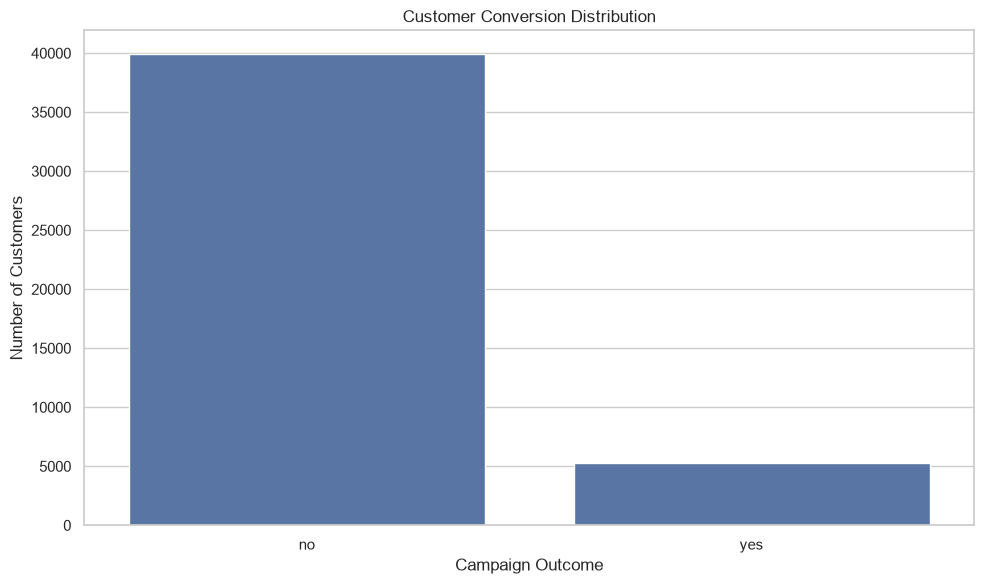

In [14]:
# ==========================================================
# Customer Conversion Distribution
# ==========================================================

separator("CUSTOMER CONVERSION DISTRIBUTION")

plot_conversion_distribution(df)


AGE DISTRIBUTION


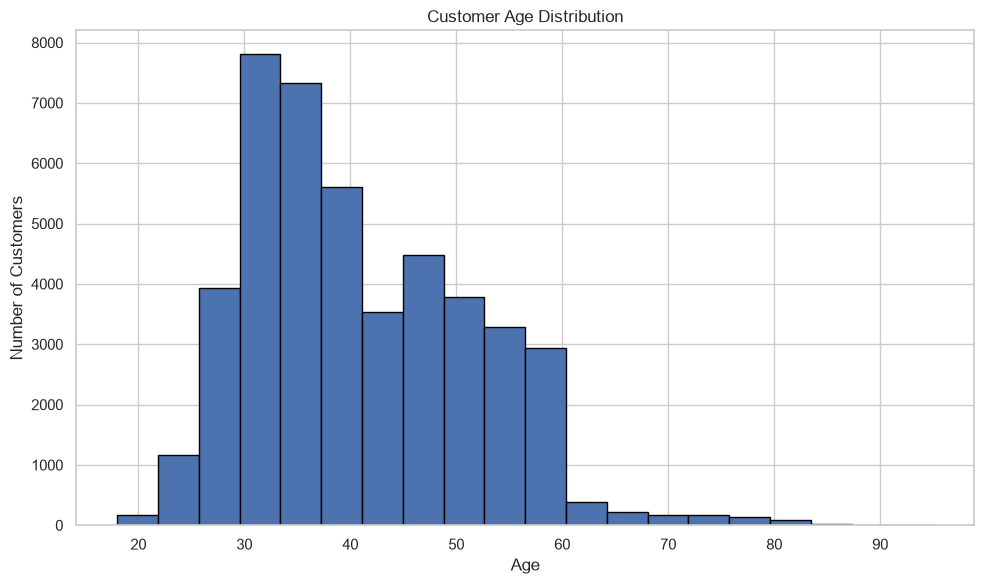

In [15]:
# ==========================================================
# Age Distribution
# ==========================================================

separator("AGE DISTRIBUTION")

plot_age_distribution(df)


ACCOUNT BALANCE DISTRIBUTION


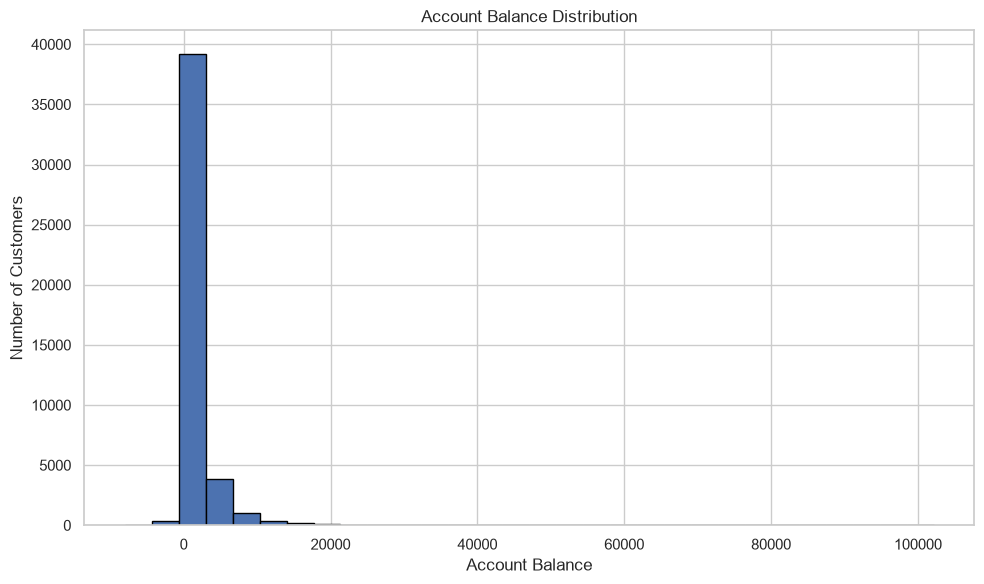

In [16]:
# ==========================================================
# Account Balance Distribution
# ==========================================================

separator("ACCOUNT BALANCE DISTRIBUTION")

plot_balance_distribution(df)


CALL DURATION DISTRIBUTION


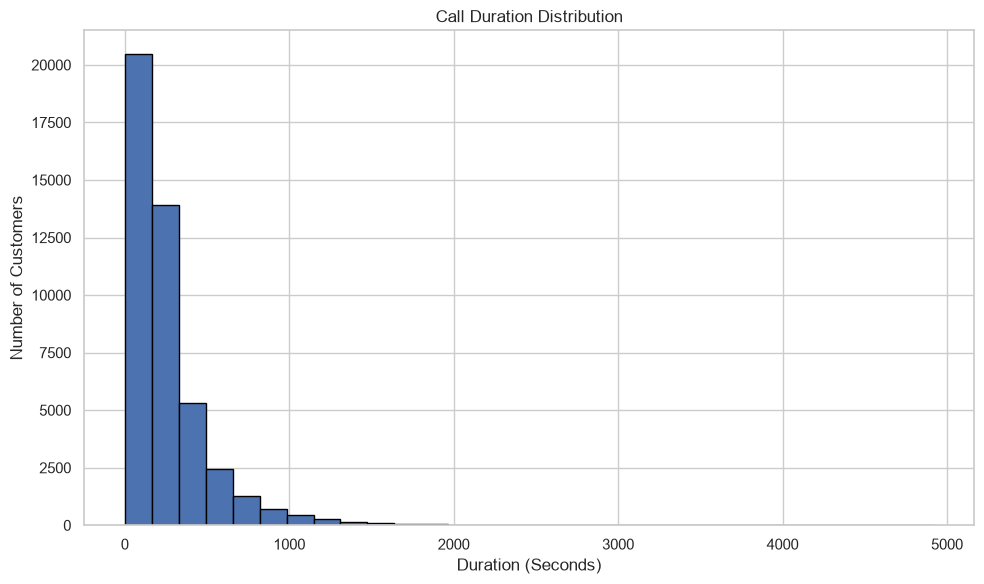

In [17]:
# ==========================================================
# Call Duration Distribution
# ==========================================================

separator("CALL DURATION DISTRIBUTION")

plot_duration_distribution(df)


CAMPAIGN CONTACT DISTRIBUTION


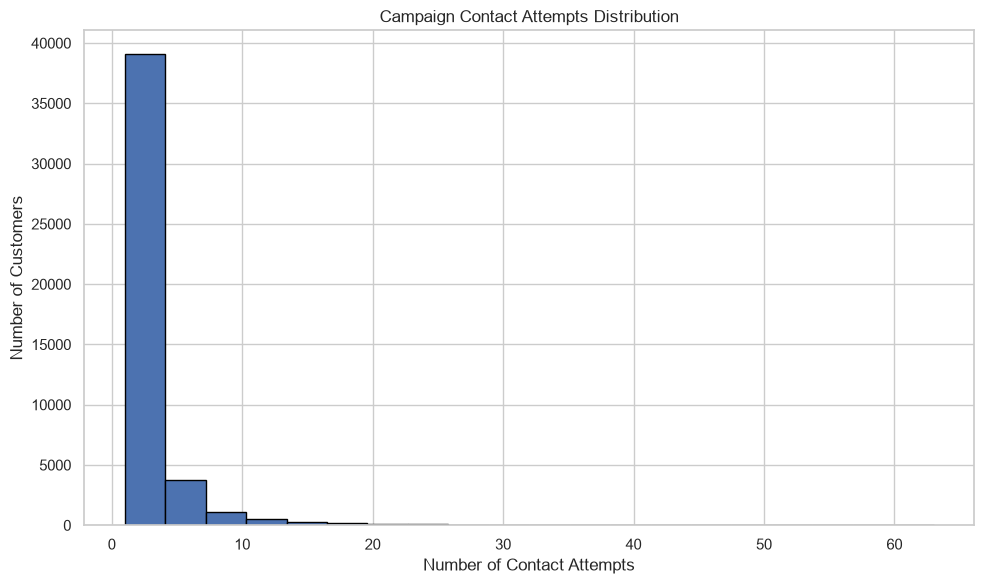

In [18]:
# ==========================================================
# Campaign Contact Distribution
# ==========================================================

separator("CAMPAIGN CONTACT DISTRIBUTION")

plot_campaign_distribution(df)


ACCOUNT BALANCE BY CAMPAIGN OUTCOME


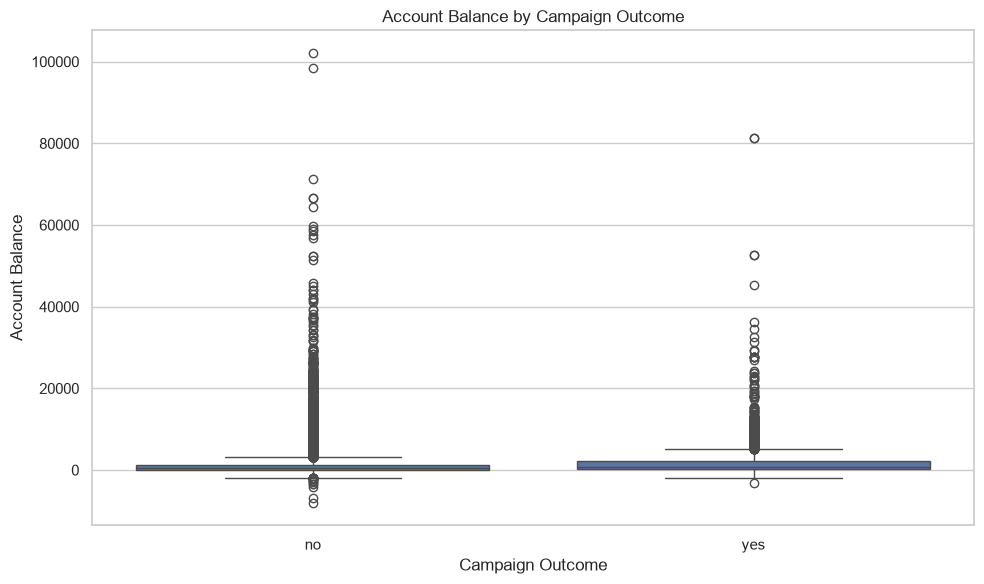

In [19]:
# ==========================================================
# Account Balance by Campaign Outcome
# ==========================================================

separator("ACCOUNT BALANCE BY CAMPAIGN OUTCOME")

plot_balance_boxplot(df)


CALL DURATION BY CAMPAIGN OUTCOME


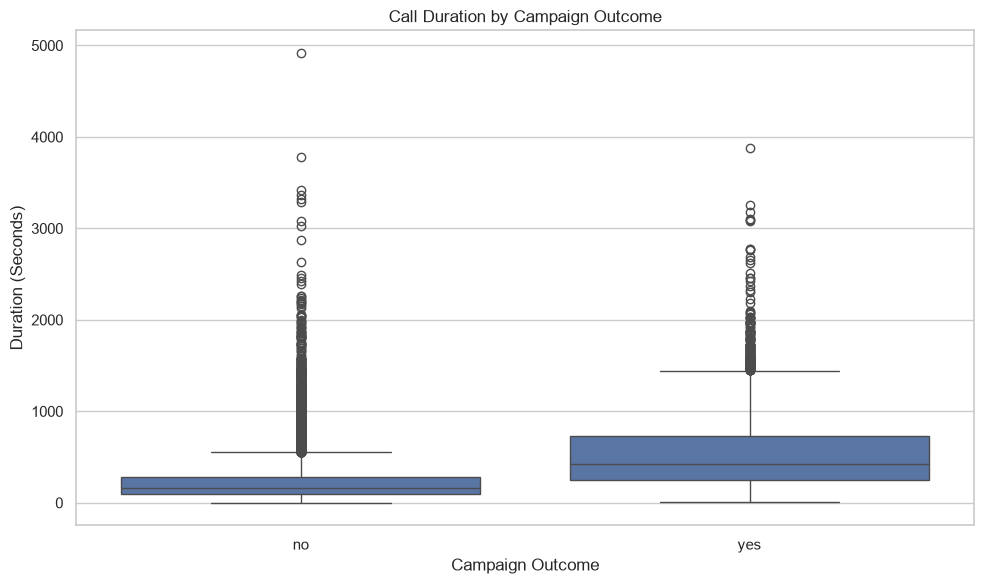

In [20]:
# ==========================================================
# Call Duration by Campaign Outcome
# ==========================================================

separator("CALL DURATION BY CAMPAIGN OUTCOME")

plot_duration_boxplot(df)


CORRELATION HEATMAP


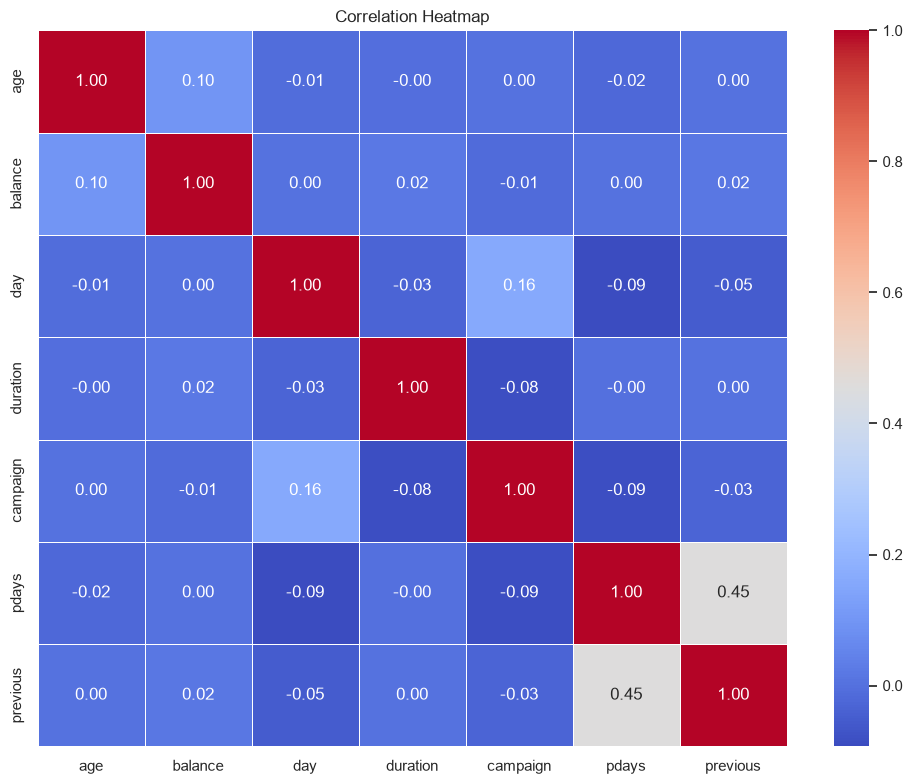

In [21]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

separator("CORRELATION HEATMAP")

plot_correlation_heatmap(corr)

# Key Findings

## Summary of Analysis

### SQL Analysis

- Overall campaign conversion rate was **11.70%**, establishing the baseline campaign performance.
- Students and retired customers demonstrated the highest conversion rates among occupation groups.
- Customers with higher account balances consistently outperformed lower-balance segments.
- Cellular communication achieved substantially better conversion than unknown communication channels.
- Previous campaign success was the strongest indicator of future conversion.
- The first contact attempt produced the highest conversion rate, with effectiveness declining as additional contact attempts increased.
- Longer call durations were strongly associated with successful campaign outcomes.

---

### Python Analysis

- Customer age is concentrated within the working-age population.
- Account balances and call durations exhibit highly right-skewed distributions.
- Converted customers generally maintain higher balances and participate in longer conversations.
- Most numerical variables show relatively weak linear correlations, suggesting that campaign performance is driven more by customer segmentation than by direct relationships among numerical features.

---

### Business Conclusion

The marketing campaign demonstrates clear opportunities for optimization through targeted customer segmentation rather than increasing contact frequency. Focusing future campaigns on high-converting customer profiles, improving communication strategy, and prioritizing customer engagement quality can significantly improve marketing efficiency while reducing unnecessary campaign costs.